<a href="https://colab.research.google.com/github/sukanya9020/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sukanya9020/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [ ]:
research_question = """
Which content items should be prioritized for review or refresh based on
recent search performance, content age, update history, visibility, and
engagement signals?
"""

decision = """
The decision supported by this analysis is which content items a content or
SEO practitioner should review first. The output will be a ranked list of
content opportunities with an action recommendation and reason codes.
"""

print("Research Question:")
print(research_question)

print("Decision:")
print(decision)

Research Question:

Which content items should be prioritized for review or refresh based on
recent search performance, content age, update history, visibility, and
engagement signals?

Decision:

The decision supported by this analysis is which content items a content or
SEO practitioner should review first. The output will be a ranked list of
content opportunities with an action recommendation and reason codes.



## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [ ]:
import pandas as pd

DATA_URL = "https://raw.githubusercontent.com/sukanya9020/flyrank-ml-internship/main/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(DATA_URL)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 30000
Columns: 44


In [ ]:
print("Column names:")
for i, column in enumerate(df.columns, start=1):
    print(i, column)

Column names:
1 content_id
2 client_id
3 search_volume
4 competition
5 competition_level
6 cpc
7 content_type
8 main_intent
9 word_count
10 char_count
11 provider_used
12 model_used
13 impressions_90d
14 clicks_90d
15 pageviews_90d
16 sessions_90d
17 users_90d
18 engaged_sessions_90d
19 ai_sessions_90d
20 scroll_events_90d
21 days_with_impressions
22 days_with_sessions
23 impressions_last_30d
24 clicks_last_30d
25 sessions_last_30d
26 impressions_prev_30d
27 clicks_prev_30d
28 sessions_prev_30d
29 content_age_days
30 age_tier
31 age_tier_order
32 days_since_last_update
33 freshness_tier
34 word_count_tier
35 char_count_tier
36 ctr
37 avg_position
38 engagement_rate
39 scroll_rate
40 ai_traffic_pct
41 impression_tier
42 position_tier
43 trend_direction
44 trend_pct


### Data Description

The analysis uses the public-safe anonymized content performance dataset provided for the FlyRank internship. The dataset contains 30,000 content records and 44 columns.

Each row represents a content item. The dataset includes content characteristics, search visibility, engagement, freshness, and recent performance signals.

For this analysis, the main fields used are:
- content_id: anonymized identifier for each content item
- content_age_days: age of the content
- days_since_last_update: time since the content was last updated
- impressions_90d: search impressions over the trailing 90 days
- clicks_90d: clicks over the trailing 90 days
- ctr: click-through rate
- avg_position: average search position
- word_count: content length
- impressions_last_30d and impressions_prev_30d: recent and previous 30-day impressions
- trend_direction and trend_pct: recent performance trend indicators

The analysis excludes identifying client information and focuses on anonymized content-level signals. The output is intended for decision support and prioritization rather than causal conclusions about search-engine algorithms or guaranteed traffic improvement.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Methodology

The project uses a content opportunity scoring approach to prioritize content items for review or refresh.

The main assumption is that a combination of content age, time since the last update, search visibility, engagement, and recent performance can provide useful signals for identifying content that may deserve human review.

The analysis uses the following features:
- content_age_days
- days_since_last_update
- impressions_90d
- clicks_90d
- ctr
- avg_position
- word_count
- impressions_last_30d
- impressions_prev_30d
- trend_pct

The target is treated as a prioritization signal rather than a claim of guaranteed future performance. Content items are ranked according to their opportunity score and assigned an action such as Review, Refresh, Monitor, or Protect.

A baseline scoring approach is used first. Model-based scoring is then compared with the baseline using the same validation setup.

To reduce leakage, features are restricted to information available from the observed content-performance data, and identifiers such as content_id and client_id are not used as predictive features.

The final recommendations are intended as decision-support signals for content practitioners. They do not establish that refreshing a page will cause improved search performance.

In [ ]:
import numpy as np
import pandas as pd

# Create a copy for analysis
score_df = df.copy()

# Convert selected columns to numeric values
score_columns = [
    "content_age_days",
    "days_since_last_update",
    "impressions_90d",
    "ctr",
    "avg_position",
    "trend_pct"
]

for col in score_columns:
    score_df[col] = pd.to_numeric(score_df[col], errors="coerce")

# Replace missing values with the median
for col in score_columns:
    score_df[col] = score_df[col].fillna(score_df[col].median())

# Helper function: percentile rank from 0 to 1
def percentile_score(series):
    return series.rank(pct=True)

# Positive opportunity signals
age_score = percentile_score(score_df["content_age_days"])
update_score = percentile_score(score_df["days_since_last_update"])
visibility_score = percentile_score(score_df["impressions_90d"])

# Lower CTR can indicate an opportunity when visibility exists
low_ctr_score = 1 - percentile_score(score_df["ctr"])

# Negative trend can indicate a potential review opportunity
trend_score = percentile_score(-score_df["trend_pct"])

# Baseline opportunity score
score_df["opportunity_score"] = (
    0.25 * age_score +
    0.25 * update_score +
    0.20 * visibility_score +
    0.15 * low_ctr_score +
    0.15 * trend_score
)

# Convert to a 0–100 scale
score_df["opportunity_score"] = score_df["opportunity_score"] * 100

# Sort highest opportunity first
baseline_results = score_df.sort_values(
    "opportunity_score",
    ascending=False
).reset_index(drop=True)

print("Baseline scoring completed!")
print("Number of content items:", len(baseline_results))

baseline_results[
    [
        "content_id",
        "content_age_days",
        "days_since_last_update",
        "impressions_90d",
        "ctr",
        "trend_pct",
        "opportunity_score"
    ]
].head(10)

Baseline scoring completed!
Number of content items: 30000


,content_id,content_age_days,days_since_last_update,impressions_90d,ctr,trend_pct,opportunity_score
0,content_0f9305fb9daa,504,104,2294,0.00,-88.8,84.534417
1,content_8ba781dafa55,348,104,16156,0.00,-85.6,84.261583
2,content_c0e96a7db2c6,333,104,8915,0.00,-96.5,83.011333
3,content_43a70ba6b218,537,104,18167,0.07,-50.6,82.301167
4,content_c8e9d6ab9013,362,104,208678,0.00,-43.4,81.833333
5,content_371e6e08c996,504,104,23265,0.10,-52.7,81.831500
6,content_2725d2bcfac1,504,104,27348,0.02,-38.9,81.797333
7,content_fb4bf6555c79,299,104,84093,0.00,-83.0,81.626500
8,content_0ac90a7368b5,545,104,2721,0.00,-45.8,81.527333
9,content_6b41450ae50c,463,104,3967,0.00,-55.5,81.438500


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Baseline Results

The baseline scoring method produced an opportunity score for all 30,000 content items.

The score combines five types of signals:
1. Content age
2. Time since the last update
3. Search visibility
4. Lower click-through rate
5. Negative recent performance trend

Higher scores indicate stronger signals for human review or possible content refresh.

The baseline is intentionally simple and interpretable. It provides a reference point that can later be compared with a model-based approach using the same validation setup.

The baseline should not be interpreted as proof that a content refresh will improve performance. It is a prioritization mechanism designed to help practitioners decide which content deserves attention first.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Features available for modeling
features = [
    "content_age_days",
    "days_since_last_update",
    "impressions_90d",
    "ctr",
    "avg_position",
    "word_count"
]

# Target: recent performance trend
target = "trend_pct"

model_df = score_df[features + [target]].copy()

# Remove invalid rows
model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna()

X = model_df[features]
y = model_df[target]

# Same train/test split used for evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Train Random Forest model
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Predict on unseen test data
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model training completed!")
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("MAE:", round(mae, 2))
print("R²:", round(r2, 3))

Model training completed!
Training rows: 17840
Test rows: 4461
MAE: 75.64
R²: -0.015


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

# Simple baseline: predict the training-set mean for every test item
baseline_prediction = np.full(
    len(y_test),
    y_train.mean()
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

baseline_r2 = r2_score(
    y_test,
    baseline_prediction
)

print("Baseline evaluation")
print("Baseline MAE:", round(baseline_mae, 2))
print("Baseline R²:", round(baseline_r2, 3))

print("\nModel evaluation")
print("Model MAE:", round(mae, 2))
print("Model R²:", round(r2, 3))

Baseline evaluation
Baseline MAE: 71.89
Baseline R²: -0.0

Model evaluation
Model MAE: 75.64
Model R²: -0.015


### Model vs Baseline Results

The Random Forest model was evaluated on a held-out test set containing 4,461 records.

The simple baseline achieved a Mean Absolute Error (MAE) of 71.89, while the Random Forest model achieved an MAE of 75.64.

The baseline R² was approximately 0.000, compared with -0.015 for the Random Forest model.

Therefore, the Random Forest model did not outperform the simple baseline for predicting trend_pct in this experiment. The negative R² indicates that the model did not explain useful additional variation in the held-out target compared with the baseline prediction.

Because of this result, the model is not presented as a superior predictive model. Instead, the interpretable baseline opportunity score remains the primary prioritization mechanism, while the model experiment is reported as a validation finding and limitation.

This result also demonstrates why model evaluation is important before using a machine-learning model for decision support.

## 5. Limitations

*What this work cannot claim.*

### Limitations and Honest Framing

This analysis has several limitations.

First, the dataset contains observational content-performance signals. The analysis cannot establish that updating or refreshing a content item will cause better search performance.

Second, the Random Forest experiment did not outperform the simple baseline on the held-out test set. Therefore, the machine-learning model is not presented as a superior predictive solution.

Third, the opportunity score is a prioritization heuristic. A high score means that the observed signals suggest that a content item may deserve review; it does not mean that the content definitely needs a refresh.

Fourth, the analysis uses anonymized content-level data and does not include private client information, domains, search queries, credentials, or raw private exports.

Finally, recommendations should be reviewed by a human practitioner who can consider factors that are not represented in the dataset, such as business importance, content quality, search intent, strategic priorities, and recent changes to the content.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [ ]:
# Create action recommendations from the baseline opportunity score

recommendations = baseline_results.copy()

def assign_action(score):
    if score >= 75:
        return "Refresh"
    elif score >= 50:
        return "Review"
    elif score >= 25:
        return "Monitor"
    else:
        return "Protect"

recommendations["recommended_action"] = (
    recommendations["opportunity_score"]
    .apply(assign_action)
)

# Add simple reason codes
def create_reason(row):
    reasons = []

    if row["content_age_days"] >= score_df["content_age_days"].median():
        reasons.append("older_content")

    if row["days_since_last_update"] >= score_df["days_since_last_update"].median():
        reasons.append("long_since_update")

    if row["impressions_90d"] >= score_df["impressions_90d"].median():
        reasons.append("meaningful_visibility")

    if row["ctr"] <= score_df["ctr"].median():
        reasons.append("lower_ctr")

    if row["trend_pct"] < 0:
        reasons.append("negative_trend")

    return ", ".join(reasons) if reasons else "mixed_signals"

recommendations["reason_codes"] = recommendations.apply(
    create_reason,
    axis=1
)

# Show the top 20 recommendations
top_recommendations = recommendations[
    [
        "content_id",
        "opportunity_score",
        "recommended_action",
        "reason_codes",
        "content_age_days",
        "days_since_last_update",
        "impressions_90d",
        "ctr",
        "trend_pct"
    ]
].head(20)

print("Top 20 Content Recommendations")
display(top_recommendations)

Top 20 Content Recommendations


,content_id,opportunity_score,recommended_action,reason_codes,content_age_days,days_since_last_update,impressions_90d,ctr,trend_pct
0,content_0f9305fb9daa,84.534417,Refresh,"older_content, long_since_update, meaningful_v...",504,104,2294,0.00,-88.8
1,content_8ba781dafa55,84.261583,Refresh,"older_content, long_since_update, meaningful_v...",348,104,16156,0.00,-85.6
2,content_c0e96a7db2c6,83.011333,Refresh,"older_content, long_since_update, meaningful_v...",333,104,8915,0.00,-96.5
3,content_43a70ba6b218,82.301167,Refresh,"older_content, long_since_update, meaningful_v...",537,104,18167,0.07,-50.6
4,content_c8e9d6ab9013,81.833333,Refresh,"older_content, long_since_update, meaningful_v...",362,104,208678,0.00,-43.4
5,content_371e6e08c996,81.831500,Refresh,"older_content, long_since_update, meaningful_v...",504,104,23265,0.10,-52.7
6,content_2725d2bcfac1,81.797333,Refresh,"older_content, long_since_update, meaningful_v...",504,104,27348,0.02,-38.9
7,content_fb4bf6555c79,81.626500,Refresh,"older_content, long_since_update, meaningful_v...",299,104,84093,0.00,-83.0
8,content_0ac90a7368b5,81.527333,Refresh,"older_content, long_since_update, meaningful_v...",545,104,2721,0.00,-45.8
9,content_6b41450ae50c,81.438500,Refresh,"older_content, long_since_update, meaningful_v...",463,104,3967,0.00,-55.5


### Ranked Recommendations

The baseline opportunity score was used to create a ranked list of content items for human review.

The highest-ranked items generally combine multiple opportunity signals, including older content age, longer time since the last update, meaningful search visibility, lower CTR, and negative recent performance.

For example, the highest-ranked content item has an opportunity score of approximately 84.53. It is 504 days old, has not been updated for 104 days, has 2,294 impressions over the trailing 90 days, has a CTR of 0.00%, and has a trend of -88.8%.

The recommendations are categorized into four actions:

- Refresh: strong combination of opportunity signals requiring closer review.
- Review: moderate opportunity signals that should be examined by a practitioner.
- Monitor: weaker signals that may require observation rather than immediate action.
- Protect: relatively low opportunity scores where unnecessary changes may be avoided.

These actions are prioritization suggestions, not automatic instructions. A practitioner should review the underlying content and business context before taking action.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

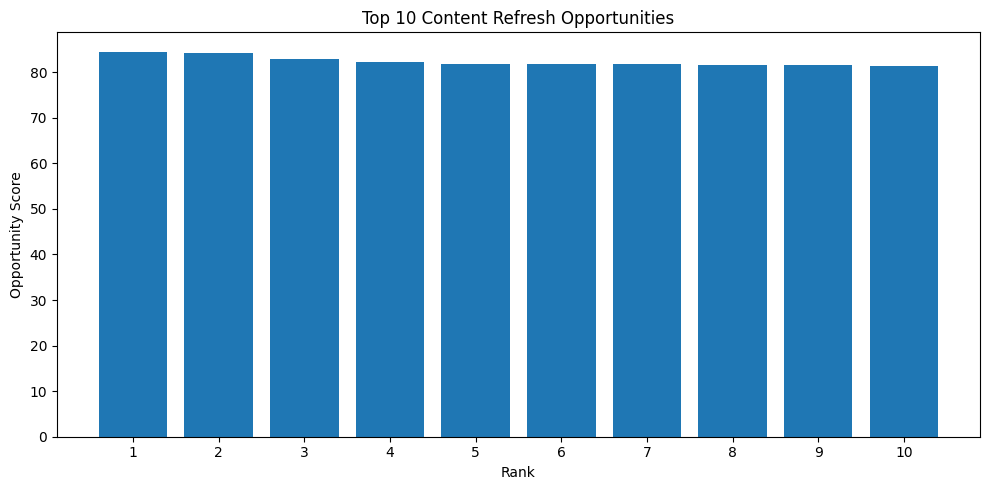

In [ ]:
import matplotlib.pyplot as plt

# Top 10 content opportunities
top10 = baseline_results.head(10).copy()

plt.figure(figsize=(10, 5))
plt.bar(
    range(1, 11),
    top10["opportunity_score"]
)

plt.xlabel("Rank")
plt.ylabel("Opportunity Score")
plt.title("Top 10 Content Refresh Opportunities")
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

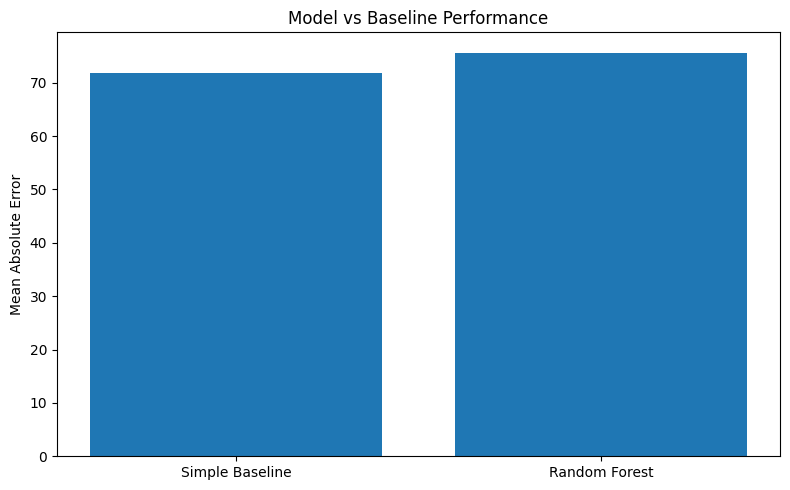

In [ ]:
import matplotlib.pyplot as plt

models = ["Simple Baseline", "Random Forest"]
mae_values = [baseline_mae, mae]

plt.figure(figsize=(8, 5))
plt.bar(models, mae_values)

plt.ylabel("Mean Absolute Error")
plt.title("Model vs Baseline Performance")
plt.tight_layout()
plt.show()

In [ ]:
# Final recommendation table for the paper

paper_table = top_recommendations.head(10).copy()

paper_table = paper_table[
    [
        "content_id",
        "opportunity_score",
        "recommended_action",
        "reason_codes"
    ]
]

display(paper_table)

,content_id,opportunity_score,recommended_action,reason_codes
0,content_0f9305fb9daa,84.534417,Refresh,"older_content, long_since_update, meaningful_v..."
1,content_8ba781dafa55,84.261583,Refresh,"older_content, long_since_update, meaningful_v..."
2,content_c0e96a7db2c6,83.011333,Refresh,"older_content, long_since_update, meaningful_v..."
3,content_43a70ba6b218,82.301167,Refresh,"older_content, long_since_update, meaningful_v..."
4,content_c8e9d6ab9013,81.833333,Refresh,"older_content, long_since_update, meaningful_v..."
5,content_371e6e08c996,81.831500,Refresh,"older_content, long_since_update, meaningful_v..."
6,content_2725d2bcfac1,81.797333,Refresh,"older_content, long_since_update, meaningful_v..."
7,content_fb4bf6555c79,81.626500,Refresh,"older_content, long_since_update, meaningful_v..."
8,content_0ac90a7368b5,81.527333,Refresh,"older_content, long_since_update, meaningful_v..."
9,content_6b41450ae50c,81.438500,Refresh,"older_content, long_since_update, meaningful_v..."


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
